In [21]:
import sys
sys.path.append('../../../')
sys.path.append('../../')

from file_management import get_files_dir,check_save_file
_, INPUT_DIR, OUTPUT_DIR = get_files_dir()

In [22]:
import pandas as pd

In [23]:
counting_data = pd.read_json('06_BIGG_X_EC_number_counts.json')

In [24]:
class_counts = pd.read_json('Correct_counts.json')

In [25]:
class_counts

,Gene,Paper_ID,Classification,Chosen_Reaction_ID,Chosen_BIGG,EC_numbers,EC_key,group_index,Reaction_Group
0,AAE,8268,Positive,[MNXR190571],ACS,[6.2.1.1],6.2.1.1,1,ACS_1
1,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",ALATA_L,[2.6.1.1],2.6.1.1,1,ALATA_L_1
2,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",ASPTA,[2.6.1.1],2.6.1.1,1,ASPTA_1
3,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",TYRTA,[2.6.1.1],2.6.1.1,1,TYRTA_1
4,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",LEUTAi,[2.6.1.1],2.6.1.1,1,LEUTAi_1
...,...,...,...,...,...,...,...,...,...
22710,zwf1,15355,Positive,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2
22711,zwf1,15789,Positive,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2
22712,zwf2,1120,Negative,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2
22713,zwf2,3017,Positive,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2


In [26]:
class_counts

,Gene,Paper_ID,Classification,Chosen_Reaction_ID,Chosen_BIGG,EC_numbers,EC_key,group_index,Reaction_Group
0,AAE,8268,Positive,[MNXR190571],ACS,[6.2.1.1],6.2.1.1,1,ACS_1
1,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",ALATA_L,[2.6.1.1],2.6.1.1,1,ALATA_L_1
2,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",ASPTA,[2.6.1.1],2.6.1.1,1,ASPTA_1
3,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",TYRTA,[2.6.1.1],2.6.1.1,1,TYRTA_1
4,AAT1,13075,Negative,"[MNXR95698, MNXR192556, MNXR105000, MNXR192685...",LEUTAi,[2.6.1.1],2.6.1.1,1,LEUTAi_1
...,...,...,...,...,...,...,...,...,...
22710,zwf1,15355,Positive,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2
22711,zwf1,15789,Positive,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2
22712,zwf2,1120,Negative,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2
22713,zwf2,3017,Positive,[MNXR192434],G6PDH2r,[1.1.1.49],1.1.1.49,2,G6PDH2r_2


In [27]:
original_df = pd.read_json('Test_normalised_classifed.json')
original_df = original_df.loc[:,['Title','Organism']]

In [28]:
df_titles= original_df

In [29]:
daniel_file = class_counts.loc[:,['Gene','Paper_ID','Classification','EC_numbers','Reaction_Group']]

In [30]:
daniel_file.Classification.value_counts()

Positive    11487
Negative     8654
Other        2574
Name: Classification, dtype: int64

In [31]:
# Make sure df_titles index is the Paper_ID
df_titles.index.name = "Paper_ID"

# Merge daniel_file with df_titles using Paper_ID
daniel_file_merged = daniel_file.merge(
    df_titles[['Title', 'Organism']],
    how='left',
    left_on='Paper_ID',
    right_index=True
)

In [32]:
daniel_file_merged

,Gene,Paper_ID,Classification,EC_numbers,Reaction_Group,Title,Organism
0,AAE,8268,Positive,[6.2.1.1],ACS_1,Complete biosynthesis of cannabinoids and thei...,[Saccharomyces cerevisiae]
1,AAT1,13075,Negative,[2.6.1.1],ALATA_L_1,A DNA assembly toolkit to unlock the CRISPR/Ca...,"[Yarrowia lipolytica, Escherichia coli]"
2,AAT1,13075,Negative,[2.6.1.1],ASPTA_1,A DNA assembly toolkit to unlock the CRISPR/Ca...,"[Yarrowia lipolytica, Escherichia coli]"
3,AAT1,13075,Negative,[2.6.1.1],TYRTA_1,A DNA assembly toolkit to unlock the CRISPR/Ca...,"[Yarrowia lipolytica, Escherichia coli]"
4,AAT1,13075,Negative,[2.6.1.1],LEUTAi_1,A DNA assembly toolkit to unlock the CRISPR/Ca...,"[Yarrowia lipolytica, Escherichia coli]"
...,...,...,...,...,...,...,...
22710,zwf1,15355,Positive,[1.1.1.49],G6PDH2r_2,Engineering Yarrowia lipolytica for the produc...,[Yarrowia lipolytica]
22711,zwf1,15789,Positive,[1.1.1.49],G6PDH2r_2,Efficient production of astaxanthin in <i>Yarr...,[Yarrowia lipolytica]
22712,zwf2,1120,Negative,[1.1.1.49],G6PDH2r_2,Antibiotic overproduction in Streptomyces coel...,[Streptomyces coelicolor]
22713,zwf2,3017,Positive,[1.1.1.49],G6PDH2r_2,Genome-scale metabolic network guided engineer...,"[Clostridium acetobutylicum, Escherichia coli,..."


In [33]:
daniel_file_merged.to_csv('gene_clasification_ec_number_title_grouped_v2.csv')

In [35]:
daniel_file.to_json('Gene_EC_numbers_Modification.json')

In [36]:
import cobra

# Load models
model1 = cobra.io.load_json_model('/Users/elisamarquez/Downloads/e_coli_core.json')
model2 = cobra.io.load_json_model('/Users/elisamarquez/Downloads/iJO1366.json')

Set parameter Username
Academic license - for non-commercial use only - expires 2026-01-15


In [37]:
counting_data.head()

,Reaction_Group,Chosen_BIGG,EC_key,Gene,Paper_ID,Classification,Chosen_Reaction_ID,EC_numbers,Organisms
0,13PPDH_1,13PPDH,1.1.1.202,"[dhaT, DhaT]","[6372, 2821, 2918, 9128, 10570, 7307, 4012, 42...","[Positive, Negative, Other]","[MNXR95727, MNXR94691]",[1.1.1.202],"[Yarrowia lipolytica, Shimwellia blattae, Clos..."
1,1P2CBXLR_1,1P2CBXLR,1.5.1.21,[dpkA],"[7704, 8273, 8945]",[Positive],"[MNXR106884, MNXR94711, MNXR94712]",[1.5.1.21],"[Pseudomonas putida, Corynebacterium glutamicum]"
2,1PPDCRc_1,1PPDCRc,1.5.1.21,[dpkA],"[7704, 8273, 8945]",[Positive],"[MNXR106884, MNXR94711, MNXR94712]",[1.5.1.21],"[Pseudomonas putida, Corynebacterium glutamicum]"
3,1PPDCRp;1PPDCRp_1_1,1PPDCRp;1PPDCRp_1,1.5.1.21,[dpkA],"[7704, 8273, 8945]",[Positive],"[MNXR106884, MNXR94711, MNXR94712]",[1.5.1.21],"[Pseudomonas putida, Corynebacterium glutamicum]"
4,23PDE2pp_1,23PDE2pp,3.1.4.16,[yfkN],[12856],[Negative],"[MNXR190422, MNXR190450, MNXR190454, MNXR19045...",[3.1.4.16],[Bacillus subtilis]


In [38]:
summary=counting_data

In [39]:
summary.head()

,Reaction_Group,Chosen_BIGG,EC_key,Gene,Paper_ID,Classification,Chosen_Reaction_ID,EC_numbers,Organisms
0,13PPDH_1,13PPDH,1.1.1.202,"[dhaT, DhaT]","[6372, 2821, 2918, 9128, 10570, 7307, 4012, 42...","[Positive, Negative, Other]","[MNXR95727, MNXR94691]",[1.1.1.202],"[Yarrowia lipolytica, Shimwellia blattae, Clos..."
1,1P2CBXLR_1,1P2CBXLR,1.5.1.21,[dpkA],"[7704, 8273, 8945]",[Positive],"[MNXR106884, MNXR94711, MNXR94712]",[1.5.1.21],"[Pseudomonas putida, Corynebacterium glutamicum]"
2,1PPDCRc_1,1PPDCRc,1.5.1.21,[dpkA],"[7704, 8273, 8945]",[Positive],"[MNXR106884, MNXR94711, MNXR94712]",[1.5.1.21],"[Pseudomonas putida, Corynebacterium glutamicum]"
3,1PPDCRp;1PPDCRp_1_1,1PPDCRp;1PPDCRp_1,1.5.1.21,[dpkA],"[7704, 8273, 8945]",[Positive],"[MNXR106884, MNXR94711, MNXR94712]",[1.5.1.21],"[Pseudomonas putida, Corynebacterium glutamicum]"
4,23PDE2pp_1,23PDE2pp,3.1.4.16,[yfkN],[12856],[Negative],"[MNXR190422, MNXR190450, MNXR190454, MNXR19045...",[3.1.4.16],[Bacillus subtilis]


In [40]:
import pandas as pd
from itertools import combinations

# -------------------
# Explode sets into one row per (Paper_ID, EC, Chosen_BIGG)
# -------------------
rows = []
for _, r in summary.iterrows():
    paper_ids = r['Paper_ID'] if isinstance(r['Paper_ID'], (set, list)) else {r['Paper_ID']}
    ecs = r['EC_numbers'] if isinstance(r['EC_numbers'], (set, list)) else {r['EC_numbers']}
    for pid in paper_ids:
        for ec in ecs:
            rows.append({
                'Chosen_BIGG': r['Chosen_BIGG'],
                'Reaction_Group': r['Reaction_Group'],
                'Paper_ID': pid,
                'EC': ec
            })

exploded = pd.DataFrame(rows)

# -------------------
# Binary per paper: keep at most one (EC, Paper) pair
# -------------------
ec_paper_binary = exploded.drop_duplicates(subset=['EC', 'Paper_ID'])

# Number of unique papers mentioning each EC
ec_docfreq = ec_paper_binary.groupby('EC')['Paper_ID'].nunique().reset_index(name='num_papers_mentioning')
ec_docfreq = ec_docfreq.sort_values('num_papers_mentioning', ascending=False)

In [41]:
exploded

,Chosen_BIGG,Reaction_Group,Paper_ID,EC
0,13PPDH,13PPDH_1,6372,1.1.1.202
1,13PPDH,13PPDH_1,2821,1.1.1.202
2,13PPDH,13PPDH_1,2918,1.1.1.202
3,13PPDH,13PPDH_1,9128,1.1.1.202
4,13PPDH,13PPDH_1,10570,1.1.1.202
...,...,...,...,...
20385,r1411,r1411_1,14293,3.2.1.23
20386,r1411,r1411_1,11239,3.2.1.23
20387,r1411,r1411_1,7145,3.2.1.23
20388,r1411,r1411_1,8170,3.2.1.23


In [42]:
ec_docfreq

,EC,num_papers_mentioning
0,1.1.1.1,279
61,1.1.1.49,175
315,2.3.1.8,164
135,1.2.1.12,160
28,1.1.1.27,155
...,...,...
178,1.3.1.25,1
177,1.3.1.14,1
682,4.1.1.2,1
174,1.3.1.104,1


# Normal EC frequency 

In [45]:
from Bio.KEGG import REST
import pandas as pd
import re

# -------------------------------------------------------------
# 1. Get the top 25 ECs from ec_docfreq
# -------------------------------------------------------------
top_ecs = ec_docfreq.head(25)['EC'].tolist()

ec_info_list = []

# -------------------------------------------------------------
# 2. Query KEGG for NAME and CLASS
# -------------------------------------------------------------
for ec in top_ecs:

    try:
        entry = REST.kegg_get(f"ec:{ec}").read()
    except Exception:
        entry = ""

    # ---- Extract NAME (multiple continuation lines allowed)
    name_lines = re.findall(r"NAME\s+(.+)|^\s{12}(.+)", entry, re.MULTILINE)
    name_list = [n[0] if n[0] else n[1] for n in name_lines if n[0] or n[1]]
    name_str = "; ".join(name_list) if name_list else ""

    # ---- Extract CLASS
    class_lines = re.findall(r"CLASS\s+(.+)|^\s{12}(.+)", entry, re.MULTILINE)
    class_list = [c[0] if c[0] else c[1] for c in class_lines if c[0] or c[1]]
    class_str = "; ".join(class_list) if class_list else ""

    # ---- Get number of papers from ec_docfreq
    num_papers = int(ec_docfreq.loc[ec_docfreq['EC'] == ec, 'num_papers_mentioning'].values[0])

    ec_info_list.append({
        "EC": ec,
        "num_papers": num_papers,
        "NAME": name_str,
        "CLASS": class_str
    })

# -------------------------------------------------------------
# 3. Build final DataFrame
# -------------------------------------------------------------
top25_ec_df = pd.DataFrame(ec_info_list).sort_values('num_papers', ascending=False)

In [ ]:
top25_ec_df.to_json('ec_BIO.json')

In [ ]:
top25_ec_df = pd.DataFrame(ec_info_list).sort_values('num_papers', ascending=False)

In [ ]:
top25_ec_df

In [ ]:
top25_ec_df.loc[7,'NAME'] = 'Phosphorus transferases'
top25_ec_df.loc[24,'NAME'] = 'Acetyl-CoA synthetase'

In [ ]:
new = top25_ec_df.NAME.str.capitalize().str[0]
top25_ec_df.NAME = new + top25_ec_df.NAME.str[1:]

In [ ]:
top25_ec_df.NAME = top25_ec_df.NAME.str.split('\(N').str[0]

In [ ]:
top25_ec_df.NAME = top25_ec_df.NAME.str.split('\([ap]').str[0]

## Plot

In [ ]:
# Make a clean EC-exploded table
ec_expanded = class_counts.explode("EC_numbers").rename(columns={"EC_numbers": "EC"})



ec_class_binary = ec_expanded.drop_duplicates(
    subset=["EC", "Paper_ID", "Classification"]
)


ec_class_counts = (
    ec_class_binary
    .groupby(["EC", "Classification"])["Paper_ID"]
    .nunique()
    .reset_index(name="num_papers")
)

In [ ]:
ec_class_binary = ec_expanded.drop_duplicates(
    subset=["EC", "Paper_ID", "Classification"]
)

In [ ]:
ec_class_counts = (
    ec_class_binary
    .groupby(["EC", "Classification"])["Paper_ID"]
    .nunique()
    .reset_index(name="num_papers")
)

In [ ]:
ec_class_counts

In [ ]:
# Pivot classification counts: EC → Positive, Negative, Other
ec_class_pivot = (
    ec_class_counts
    .pivot_table(index='EC',
                 columns='Classification',
                 values='num_papers',
                 fill_value=0)
    .reset_index()
)

# Merge with top25_ec_df to add names
top25_plot_df = top25_ec_df.merge(ec_class_pivot, on='EC', how='left')

# First part of NAME
top25_plot_df['Name_short'] = top25_plot_df['NAME'].str.split(';').str[0]

In [ ]:
ec_class_pivot

In [ ]:
top25_plot_df['Total'] = top25_plot_df['Positive'] + top25_plot_df['Negative'] + top25_plot_df['Other']
top25_plot_df = top25_plot_df.sort_values('Total', ascending=False)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 9))

x = np.arange(len(top25_plot_df))

plt.bar(x, top25_plot_df['Positive'], label='Positive', color='#D18EBA')
plt.bar(x, -top25_plot_df['Negative'], label='Negative', color='#88ACC1')

plt.axhline(0, color='black', lw=1)
#plt.title('Top 25 Enzymes (by EC Number) Most Frequently Reported as Up- or Down-Regulated in the Literature', fontsize=20, pad=20)
plt.ylabel('Number of Papers', fontsize=12)

# X-axis labels = short EC names
plt.xticks(
    x,
    top25_plot_df['Name_short'],
    rotation=45,
    ha='right',
    fontsize=12
)

# Add value labels above/below bars
for i, (pos, neg) in enumerate(zip(top25_plot_df['Positive'], top25_plot_df['Negative'])):
    if pos > 0:
        plt.text(i, pos + 0.3, str(pos), ha='center', fontsize=10)
    if neg > 0:
        plt.text(i, -neg - 7, str(neg), ha='center', fontsize=10)

ticks = plt.gca().get_yticks()
plt.gca().set_yticklabels([int(abs(t)) for t in ticks])
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
top25_plot_df = top25_plot_df.head(20)
top25_plot_df = top25_plot_df.sort_values('Total', ascending=True)

In [ ]:
top25_plot_df

In [ ]:
short_labels = [
    "DAHP synthase",
    "Chorismate mutase",
    "Transaldolase",
    "Acetate kinase",
    "Aldehyde dehydrogenase",
    "PEP carboxylase",
    "Malate DH",
    "Pyruvate kinase",
    "Transketolase",
    "Indolepyruvate decarboxylase",
    "OMP decarboxylase",
    "D-lactate DH",
    "HM-GSH dehydrogenase",
    "Phosphotransferases",
    "G6P isomerase",
    "L-lactate DH",
    "GAP dehydrogenase",
    "Phosphate acetyltransferase",
    "G6P dehydrogenase",
    "Alcohol DH"
]

In [ ]:
top25_plot_df.Name_short = short_labels

/var/folders/v6/y2v6wwn93yj5vvhl558fx2zc0000gn/T/ipykernel_52608/2448587090.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels([int(abs(t)) for t in ticks], fontsize=20)


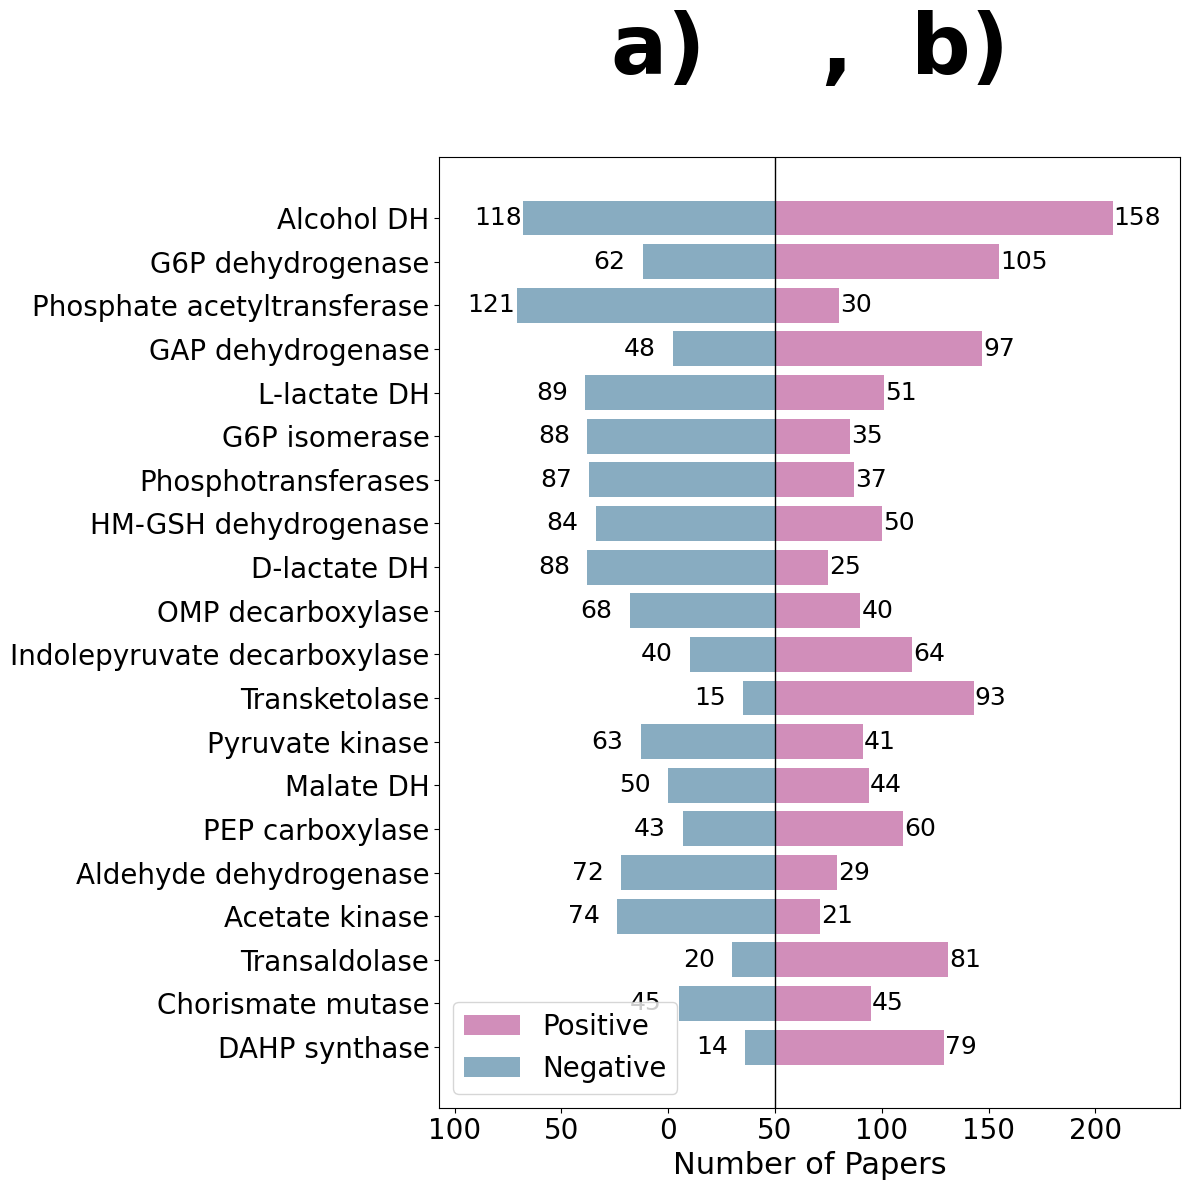

In [604]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # <-- keeps text editable in Illustrator
mpl.rcParams['ps.fonttype'] = 42    # <-- same for PS/PDF backends

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))

y = np.arange(len(top25_plot_df))

# Horizontal bars (positive to the right, negative to the left)
plt.barh(y, top25_plot_df['Positive'], label='Positive', color='#D18EBA')
plt.barh(y, -top25_plot_df['Negative'], label='Negative', color='#88ACC1')

plt.axvline(0, color='black', lw=1)
plt.xlabel('Number of Papers', fontsize=22)

# Y-axis labels = short EC names
plt.yticks(
    y,
    top25_plot_df['Name_short'],
    fontsize=20
)

# Add value labels next to bars
for i, (pos, neg) in enumerate(zip(top25_plot_df['Positive'], top25_plot_df['Negative'])):
    if pos > 0:
        plt.text(pos + 0.5, i, str(pos), va='center', fontsize=18)
    if neg > 0:
        plt.text(-neg - 23, i, str(neg), va='center', fontsize=18)

# Replace x-axis tick labels with absolute values
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(abs(t)) for t in ticks], fontsize=20)

# Extra space left and right
max_val_p = top25_plot_df['Positive'].max()
max_val_n = top25_plot_df['Negative'].max()
plt.xlim(-max_val_n * 1.3, max_val_p * 1.2)

plt.title('a)    ,  b)', fontsize=60, fontweight='bold', pad=60)
plt.legend(fontsize=20)
plt.tight_layout()

plt.savefig("myImagePDF.pdf", format="pdf", bbox_inches="tight")
plt.show()

# EC X BIGG frequency 

In [51]:

# -------------------
# Explode sets into one row per (Paper_ID, EC, Chosen_BIGG)
# -------------------
rows = []
for _, r in summary.iterrows():
    paper_ids = r['Paper_ID'] if isinstance(r['Paper_ID'], (set, list)) else {r['Paper_ID']}
    ecs = r['EC_numbers'] if isinstance(r['EC_numbers'], (set, list)) else {r['EC_numbers']}
    for pid in paper_ids:
        for ec in ecs:
            rows.append({
                'Chosen_BIGG': r['Chosen_BIGG'],
                'Reaction_Group': r['Reaction_Group'],
                'Paper_ID': pid,
                'EC': ec
            })

exploded = pd.DataFrame(rows)
# -------------------
# Binary per paper: keep at most one (EC, Paper) pair
# -------------------
ec_paper_binary = exploded.drop_duplicates(subset=['EC', 'Paper_ID', 'Chosen_BIGG'])

# -------------------
# EC document frequency *per BIGG reaction*
# -------------------
ec_bigg_docfreq = (
    ec_paper_binary
    .groupby(['EC', 'Chosen_BIGG'])['Paper_ID']
    .nunique()
    .reset_index(name='num_papers_mentioning')
    .sort_values(['EC', 'num_papers_mentioning'], ascending=[True, False])
)

In [52]:
ec_bigg_docfreq

,EC,Chosen_BIGG,num_papers_mentioning
0,1.1.1.1,ALCD2x,263
3,1.1.1.1,ALR2,14
2,1.1.1.1,ALDD3y,5
1,1.1.1.1,ALCDkt;ALCDpp,3
4,1.1.1.100,3OAR100,19
...,...,...,...
1650,7.5.2.1,MALTabcpp,1
1651,7.6.2.1,ATPM,4
1652,7.6.2.2,ATPM,2
1653,7.6.2.5,HEMEti;PHEME2abcpp,1


In [53]:
ec_docfreq.head(20)

,EC,num_papers_mentioning
0,1.1.1.1,279
61,1.1.1.49,175
315,2.3.1.8,164
135,1.2.1.12,160
28,1.1.1.27,155
824,5.3.1.9,141
35,1.1.1.284,135
459,2.7.1.69,133
32,1.1.1.28,118
686,4.1.1.23,118


In [54]:
ec_bigg_docfreq.sort_values('num_papers_mentioning', ascending=False).head(20)

,EC,Chosen_BIGG,num_papers_mentioning
0,1.1.1.1,ALCD2x,263
111,1.1.1.49,G6PDH2r,175
603,2.3.1.8,PTAr,164
253,1.2.1.12,GAPD,160
54,1.1.1.27,LDH_D,146
1536,5.3.1.9,PGI,141
65,1.1.1.284,ALCD2x,135
871,2.7.1.69,TREptspp,133
1335,4.1.1.23,OMPDC,118
521,2.2.1.1,TKT2,114


# Counts 

In [333]:
# Make a clean EC-exploded table
ec_expanded = class_counts.explode("Chosen_BIGG").rename(columns={"Chosen_BIGG": "EC"})



ec_class_binary = ec_expanded.drop_duplicates(
    subset=["EC", "Paper_ID", "Classification"]
)


ec_class_counts = (
    ec_class_binary
    .groupby(["EC", "Classification"])["Paper_ID"]
    .nunique()
    .reset_index(name="num_papers")
)

In [334]:
ec_class_counts.head()

,EC,Classification,num_papers
0,13PPDH,Negative,3
1,13PPDH,Other,1
2,13PPDH,Positive,8
3,1P2CBXLR,Positive,3
4,1PPDCRc,Positive,3


In [335]:
# total papers per EC
ec_totals = ec_class_counts.groupby('EC')['num_papers'].sum().reset_index()
ec_totals = ec_totals.rename(columns={'num_papers': 'total_papers'})

In [378]:
top_30 = ec_totals.sort_values('total_papers',ascending=False).head(45).EC

In [379]:
#ec_totals.sort_values('total_papers',ascending=False).head(40)

In [380]:
model2.reactions.ASPTA

Reaction identifier,ASPTA
Name,aspartate transaminase
Memory address,0x07fab392d0880
Stoichiometry,akg_c + asp__L_c <=> glu__L_c + oaa_c akg_c + asp__L_c <=> glu__L_c + oaa_c
GPR,b0928
Lower bound,-1000.0
Upper bound,1000.0


In [381]:
top_30

181            ALCD2x
686             LDH_D
240              ATPM
486           G6PDH2r
1014             PTAr
493              GAPD
910               PGI
1179         TREptspp
554              GRTT
387             DMATT
191              ALR2
856             OMPDC
657           INDPYRD
1167             TKT2
1166             TKT1
1028              PYK
896               PDH
967               PPC
92              ACALD
186            ALDD2y
1149             TALA
107              ACKr
296             CHORM
734               ME2
356              DDPA
480             G3PD2
187            ALDD3y
731               MDH
132               ACS
902               PFK
235             ASPTA
1107           SERD_L
930            PHETA1
1190            TYRTA
314                CS
1245             XYLK
688            LEUTAi
256              BTNC
220              ARAI
495            GCALDD
785              MSAR
446     FACOAL161t2pp
447     FACOAL181t2pp
518             GLUDy
644            ICDHyr
Name: EC, 

In [382]:
# merge total papers per EC
ec_class_counts_sorted = ec_class_counts.merge(ec_totals, on='EC')

# sort by total papers descending, then optional by classification
ec_class_counts_sorted = ec_class_counts_sorted.sort_values(
    ['total_papers', 'EC', 'Classification'], ascending=[False, True, True]
).reset_index(drop=True)

In [383]:
ec_class_counts_sorted.loc[:,'normalized_pie_slice_size'] = ec_class_counts_sorted.num_papers/ec_class_counts_sorted.total_papers

In [384]:
ec_class_counts_sorted

,EC,Classification,num_papers,total_papers,normalized_pie_slice_size
0,ALCD2x,Negative,124,293,0.423208
1,ALCD2x,Other,12,293,0.040956
2,ALCD2x,Positive,157,293,0.535836
3,LDH_D,Negative,161,258,0.624031
4,LDH_D,Other,25,258,0.096899
...,...,...,...,...,...
2675,URDGLYCD,Positive,1,1,1.000000
2676,URFGTT,Positive,1,1,1.000000
2677,USHD,Positive,1,1,1.000000
2678,VALTRS,Negative,1,1,1.000000


In [385]:
top_30_sorted = ec_class_counts_sorted.loc[ec_class_counts_sorted.EC.isin(top_30)]

In [411]:
# Pivot correctly and keep EC as column
ec_pivot = top_30_sorted.pivot_table(
    index='EC',               # EC as index
    columns='Classification',
    values='num_papers',
    fill_value=0
).reset_index()               # EC becomes a column after reset_index

# Check columns
print(ec_pivot.columns)
# Should be: Index(['EC', 'Negative', 'Other', 'Positive'], dtype='object', name='Classification')

Index(['EC', 'Negative', 'Other', 'Positive'], dtype='object', name='Classification')


In [434]:
ignore_reactions = ['CHORM','ALDD3y','ALR2','DMATT','ATPM','MSAR',
                    'DDPA','INDPYRD','GRTT','OMPDC','TREptspp',
                    'BTNC','ARAI','XYLK',
                    'FACOAL181t2pp','FACOAL161t2pp','SERD_L']

AA = ['PHETA1','SERD_L','TYRTA','LEUTAi']

In [435]:
ec_pivot_chosen_reactions = ec_pivot.loc[~ec_pivot.EC.isin(ignore_reactions)]

In [436]:
rows = []
label_order = ["Positive", "Negative", "Other"]

for _, row in ec_pivot_chosen_reactions.iterrows():
    ec_id = row["EC"]  # use the EC string, not the row index
    total = row[label_order].sum()

    # EC header row
    rows.append([ec_id, "Abundance", total])

    # Classification rows
    for i, label in enumerate(label_order):
        if i == 0:
            fragment_name = f"{ec_id}"  # Positive first
        else:
            fragment_name = f"{ec_id}({label})"
        value = row[label] / total if total != 0 else 0
        rows.append(["", fragment_name, value])

formatted_df = pd.DataFrame(rows, columns=["Reaction", "Fragment", "Values"])

In [437]:
formatted_df = pd.DataFrame(rows, columns=["Reaction", "Fragment", "Values"])

# Inspect
print(formatted_df.head(10))

# Optional: save to CSV
formatted_df.to_csv("../../Mapa/ec_fragments.csv", index=False)

  Reaction         Fragment      Values
0    ACALD        Abundance  108.000000
1                     ACALD    0.268519
2           ACALD(Negative)    0.666667
3              ACALD(Other)    0.064815
4     ACKr        Abundance  107.000000
5                      ACKr    0.196262
6            ACKr(Negative)    0.691589
7               ACKr(Other)    0.112150
8      ACS        Abundance   99.000000
9                       ACS    0.717172


In [438]:
formatted_df.sort_values('Values',ascending=False).head(60)

,Reaction,Fragment,Values
12,ALCD2x,Abundance,293.000000
52,LDH_D,Abundance,258.000000
32,G6PDH2r,Abundance,189.000000
88,PTAr,Abundance,181.000000
36,GAPD,Abundance,165.000000
76,PGI,Abundance,142.000000
104,TKT2,Abundance,115.000000
100,TKT1,Abundance,115.000000
92,PYK,Abundance,111.000000
68,PDH,Abundance,111.000000


In [439]:
import cobra
model = cobra.io.load_json_model('/Users/elisamarquez/Documents/PhD/Utimo/Escher_pie_plots/escher-custom-tooltips/escher-demo/knockout/e_coli_core.json')